In [33]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt

In [315]:
from sklearn.datasets import make_blobs

x, y = make_blobs(n_samples=100, centers=[[5, 5], [0, 0]])
xs = 2.5
ys = 2.5

# x = np.array([[-454.165767, -199.073559],
#                 [-294.891711, -57.151846],
#                 [24.439129, 98.905128],
#                 [-39.268611, -51.183485]])
# y = np.array([0, 0, 1, 1])
# xs = -190.093064
# ys = -70.832017

x = np.array([[28.680488, 51.825823],
                [-57.739206, 153.028673],
                [-13.354945, 170.194946],
                [46.312328, 100.320849],
                [280.253503, -173.638853],])
y = np.array([1, 1, 0, 0, 0])
xs = 142.134932 
ys = -46.464900

x[:, 0] -= xs
x[:, 1] -= ys

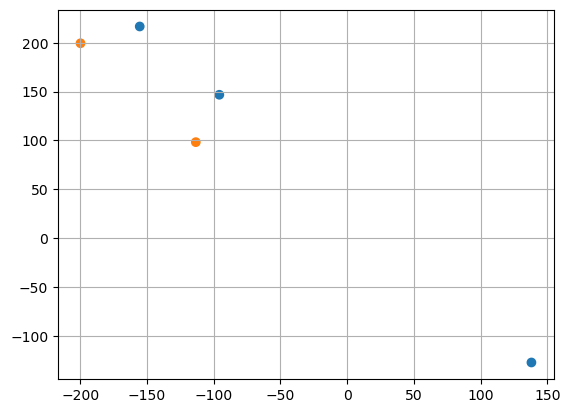

In [316]:
y_colors = [""] * y.shape[0]
for i in range(y.shape[0]):
    y_colors[i] = 'tab:orange' if y[i] == 1 else 'tab:blue'
        
plt.scatter(x[:, 0], x[:, 1], c=y_colors)
plt.grid()

In [319]:
from sklearn.svm import LinearSVC, SVC

svc = LinearSVC(random_state=39, C=0.1, fit_intercept=False, class_weight='balanced', tol=1e-9)
# svc = SVC(random_state=39, kernel='linear')
svc.fit(x, y)

LinearSVC(C=0.1, class_weight='balanced', fit_intercept=False, random_state=39,
          tol=1e-09)

In [320]:
y_pred = svc.predict(x)
y_pred_colors = [""] * y_pred.shape[0]
for i in range(y_pred.shape[0]):
    y_pred_colors[i] = 'tab:blue' if y_pred[i] == 0 else 'tab:orange'

In [321]:
xm = np.linspace(-300, 300, 100)
ym = np.linspace(-300, 300, 100)
zm = np.zeros((100, 100))

for i in range(100):
    for j in range(100):
        zm[i, j] = svc.predict([[xm[i], ym[j]]]).item()

xxm, yym = np.meshgrid(xm, ym)

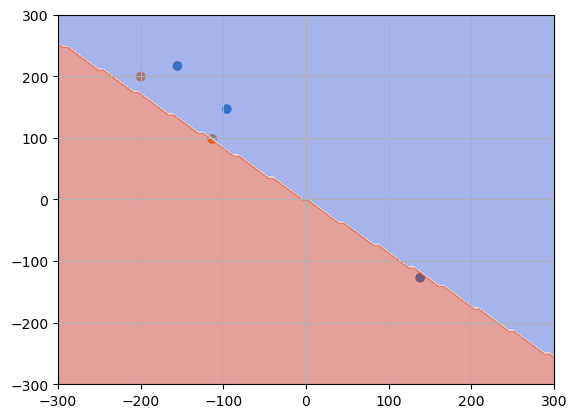

In [322]:
plt.scatter(x[:, 0], x[:, 1], c=y_pred_colors)
plt.contourf(xxm, yym, zm, alpha=0.5, cmap=plt.cm.coolwarm)
plt.grid()

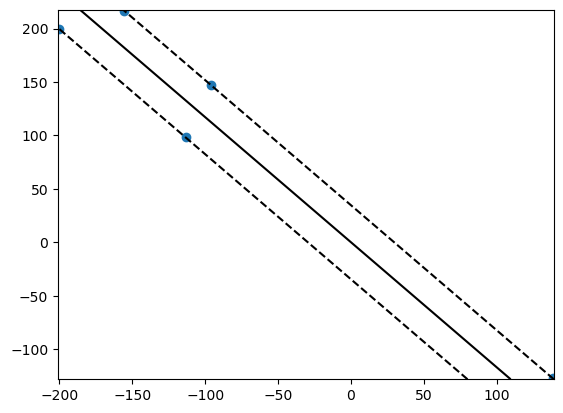

In [323]:
from sklearn.inspection import DecisionBoundaryDisplay

_, ax = plt.subplots()

DecisionBoundaryDisplay.from_estimator(
    estimator=svc,
    X=x,
    ax=ax,
    response_method="decision_function",
    plot_method="contour",
    levels=[-1, 0, 1],
    colors=["k", "k", "k"],
    linestyles=["--", "-", "--"],
)
plt.scatter(x[:, 0], x[:, 1])

In [324]:
w = svc.coef_[0]
zma = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        zma[i, j] = np.sign(w[1] * xm[i] + w[0] * ym[j])

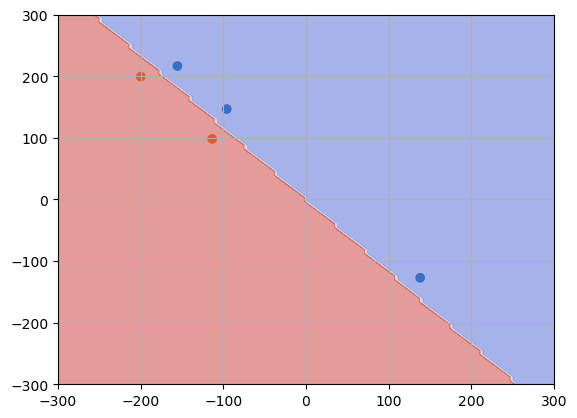

In [325]:
plt.scatter(x[:, 0], x[:, 1], c=y_pred_colors)
plt.contourf(xxm, yym, zma, alpha=0.5, cmap=plt.cm.coolwarm)
plt.grid()

In [326]:
best_dist = 1000000

for i in range(x.shape[0]):
    best_dist = min(best_dist, np.abs(w[0] * x[i, 0] + w[1] * x[i, 1]))

print(best_dist / np.sqrt(w[1] ** 2 + w[0] ** 2))

22.432335872346215
